## Visualizing the quantile discretization method

In this notebook, we inspect the RMSE of the dose-response curves predicted by quantile-binning CausalPFN. As in the uniform bin size method, we average `EPOs_1` and `EPOs_2` to get a single EPO prediction for each discretized treatment value. We do this for the same five datasets (linear, nonlinear, EconML ex 1, debt loss, and ADMIT synthetic). Run the notebook to generate files and figures (requires `epo_df` to exist)

Fix a dataset. For each `N = N_DISC`, we have an approximation to the DRF given by CausalPFN, which is a linear interpolation at the `N` treatment values. We use `scipy.interpolate.interp1d` (legacy) to define the linear interpolations from the data. For each dataset and `N` value, we estimate the RMSE on a fixed `T`-mesh, `rmse_calc_t_mesh`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from scipy.interpolate import interp1d

In [2]:
## Fix the t-mesh on which to evaluate RMSE
rmse_calc_t_mesh = np.linspace(0, 1, 100)

In [3]:
## Load DataFrames

df_linear = pd.read_csv(
    "..\output\quantile_EPO_df_vahid-linear_11-18_10h49m.csv",
    index_col=[0, 1]
)
df_nonlin = pd.read_csv(
    "..\output\quantile_EPO_df_vahid-nonlinear_11-18_10h31m.csv",
    index_col=[0, 1]
)
df_econML = pd.read_csv(
    "..\output\quantile_EPO_df_econ-ML-ex1_11-18_11h1m.csv",
    index_col=[0, 1]
)
df_debt = pd.read_csv(
    "..\output\quantile_EPO_df_debt-loss_11-18_11h37m.csv",
    index_col=[0, 1]
)
df_admit = pd.read_csv(
    "..\output\quantile_EPO_df_ADMIT-synthetic_11-18_12h27m.csv",
    index_col=[0, 1]
)

In [4]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

In [5]:
# For file naming purposes
month = datetime.datetime.now().month
date = datetime.datetime.now().day
hour = datetime.datetime.now().hour
minute = datetime.datetime.now().minute
date_string = f"{month}-{date}_{hour}h{minute}m"
file_location = "../output"

## Dataset 1: Linear DRF

In [16]:
df = df_linear 
data_name = "vahid-linear"
N_max = df.index[-1][0]

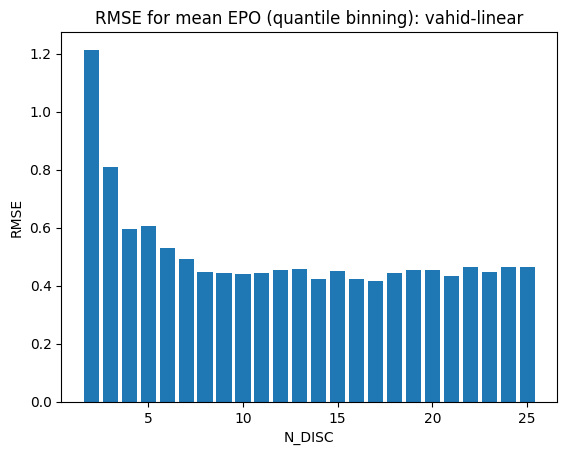

In [ ]:
# RMSE calculation on the average EPO

def drf_linear(t): return 3.5 + 3 * t # true dose-response function

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_pred_ = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    drf_pred = interp1d() ## PUT IN T VALUE TO EPO_DF
    y_true = drf_linear(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

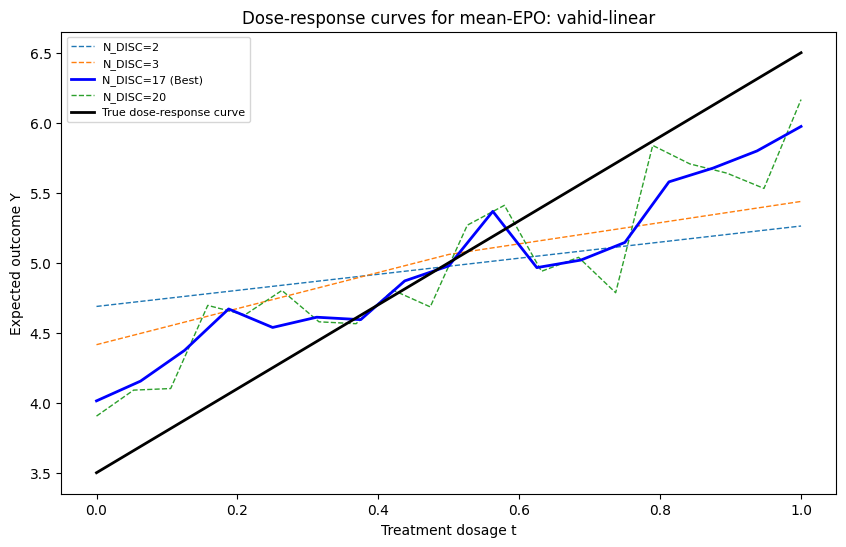

In [19]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 17, 20]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
def linear_drf(t): return 3.5 + 3 * t
t_mesh = np.linspace(0, 1, 100)
y_true = linear_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 2: Nonlinear DRF

In [5]:
df = df_nonlin
data_name = "vahid-nonlin"
N_max = df.index[-1][0]

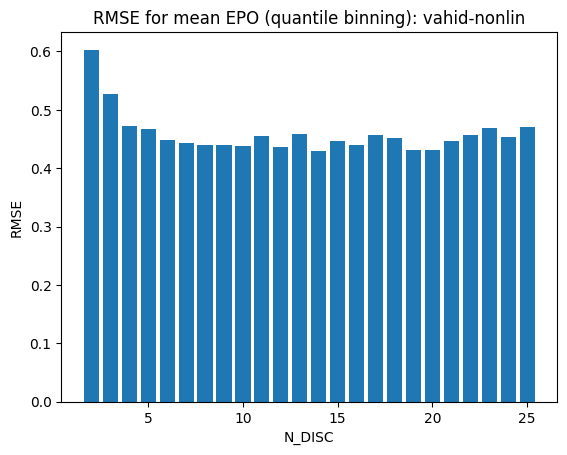

In [6]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    y_true = df_N["true_effect"].values
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

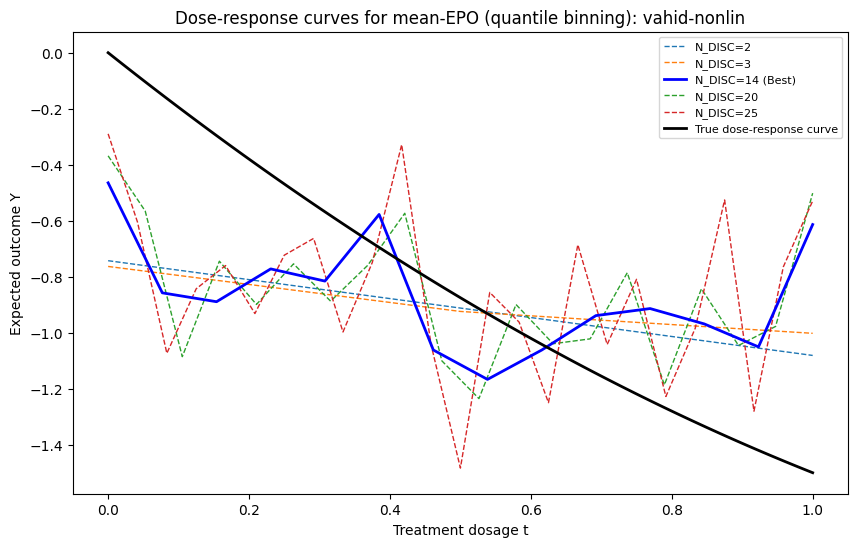

In [9]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 14, 20, 25]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
def nonlin_drf(t): return 0.5 * t ** 2 - 2 * t
t_mesh = np.linspace(0, 1, 100)
y_true = nonlin_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 3: EconML Ex 1

In [6]:
df = df_econML
data_name = "econ-ML-ex1"
N_max = df.index[-1][0]

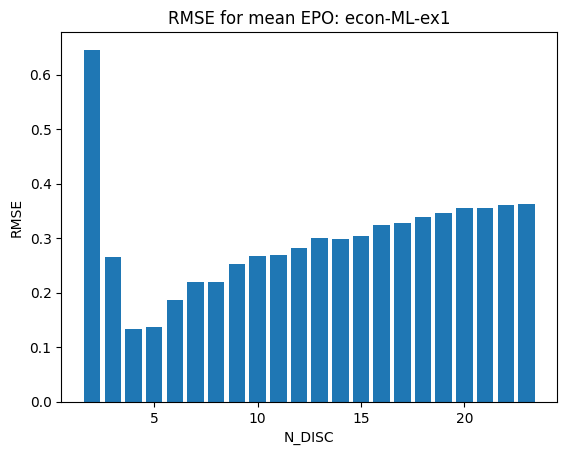

In [ ]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    y_true = df_N["true_effect"].values
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

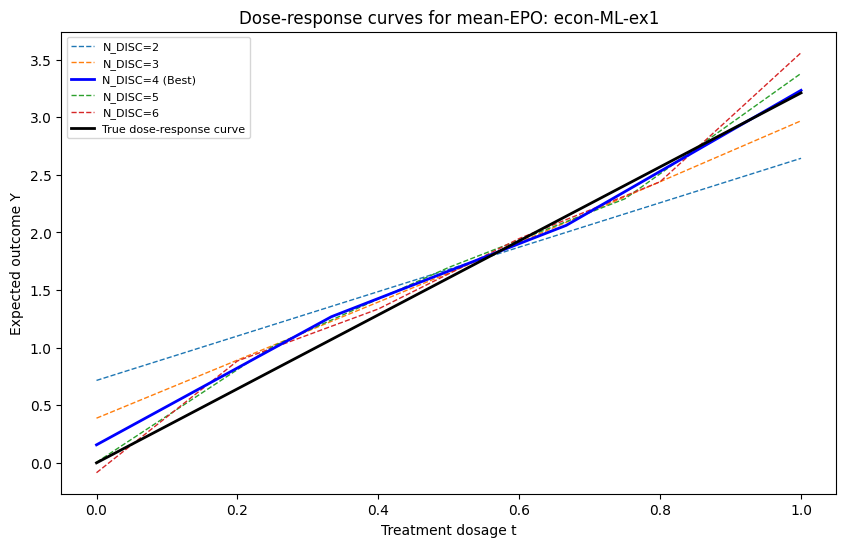

In [ ]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 4, 5, 6]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (Ran the DGP and got the coefficient of T separately)
def nonlin_drf(t): return t * 3.21182
t_mesh = np.linspace(0, 1, 100)
y_true = nonlin_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 4: Debt loss

In [22]:
df = df_debt
data_name = "debt"
N_max = df.index[-1][0]

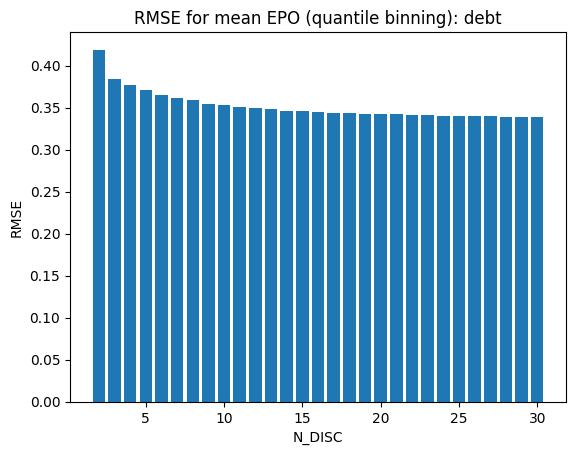

In [ ]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    y_true = df_N["true_effect"].values
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/quantile_RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

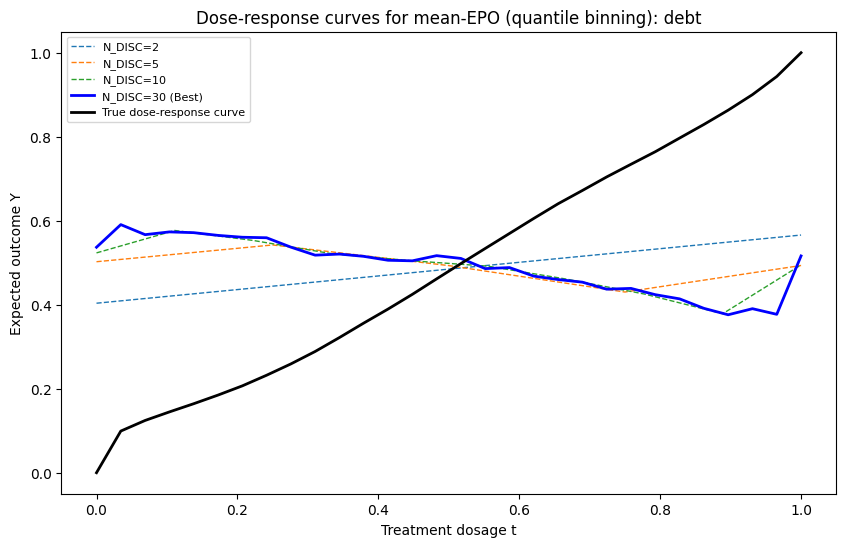

In [24]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 5, 10, 30]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (approximated by df.loc[[30]]["true_effect"])
y_true = df.loc[[30]]["true_effect"].values
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 5: ADMIT synthetic dataset

In [12]:
df = df_admit
data_name = "ADMIT-synthetic"
N_max = df.index[-1][0]

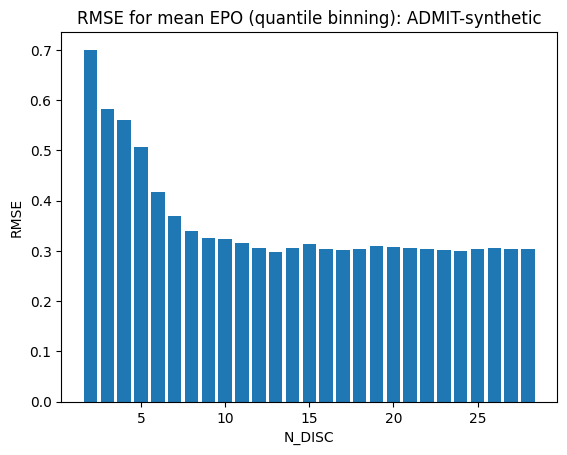

In [13]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    y_true = df_N["true_effect"].values
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")
plt.savefig(f"{file_location}/quantile_RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

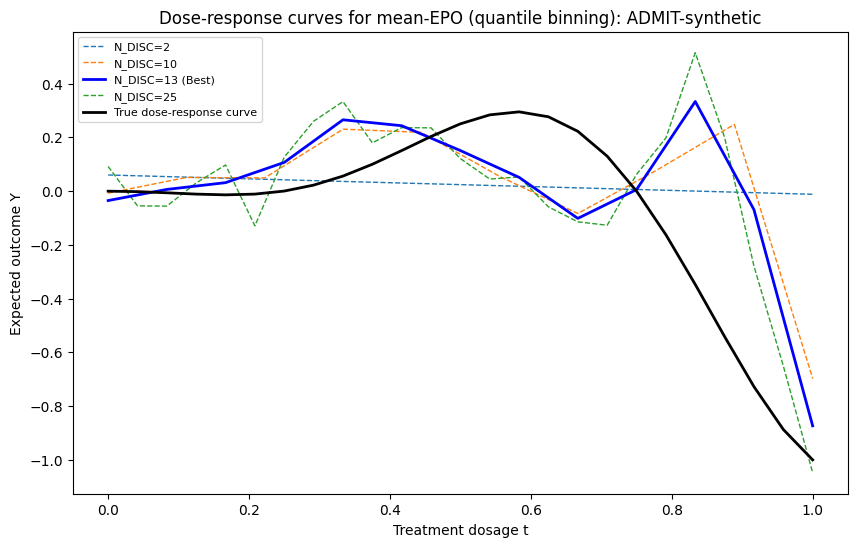

In [17]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 10, 13, 25]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (approximated by df.loc[[25]]["true_effect"])
y_true = df.loc[[25]]["true_effect"].values
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/quantile_dose-response_curves_{data_name}_{date_string}.png")

plt.show()